In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [4]:
sns.set(style="whitegrid")

In [5]:
transaction_data = pd.read_excel("C:/Users/GREATJE CMPUTERS/Desktop/MY FORAGE/QVI_transaction_data.xlsx")
customer_data = pd.read_csv("C:/Users/GREATJE CMPUTERS/Desktop/MY FORAGE/QVI_purchase_behaviour.csv")

In [6]:
transaction_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [7]:
customer_data.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [8]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], origin ='1899-12-30', unit ='D')

In [9]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [10]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


In [11]:
    transaction_data['PROD_NAME'].describe()

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [12]:
   transaction_data['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [13]:
product_words=(
       transaction_data['PROD_NAME'].str.split()
        .explode()
            .value_counts()
)
product_words.head(30)

PROD_NAME
175g        60561
Chips       49770
150g        41633
Kettle      41288
&           35565
Smiths      28860
Salt        27976
Cheese      27890
Pringles    25102
134g        25102
Doritos     24962
Crinkle     23960
110g        22387
Corn        22063
Original    21560
Cut         20754
Chip        18645
170g        18502
Salsa       18094
Chicken     15407
165g        15297
Sea         14145
Thins       14075
Sour        13882
Crisps      12607
330g        12540
Vinegar     12402
Chilli      12389
300g        12041
RRD         11894
Name: count, dtype: int64

In [14]:
product_words = product_words[~product_words.index.str.contains(r'\d')]

In [15]:
product_words = product_words[product_words.index.str.isalpha()]

In [16]:
product_words.sort_values(ascending=False).head(20)

PROD_NAME
Chips       49770
Kettle      41288
Smiths      28860
Salt        27976
Cheese      27890
Pringles    25102
Doritos     24962
Crinkle     23960
Corn        22063
Original    21560
Cut         20754
Chip        18645
Salsa       18094
Chicken     15407
Sea         14145
Thins       14075
Sour        13882
Crisps      12607
Vinegar     12402
Chilli      12389
Name: count, dtype: int64

In [17]:
transaction_data = transaction_data[
    ~transaction_data['PROD_NAME'].str.lower().str.contains("salsa")
]

In [18]:
transaction_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [19]:
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [20]:
transaction_data[transaction_data['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [21]:
outlier_customer = transaction_data.loc[
    transaction_data['PROD_QTY'] == 200,
    'LYLTY_CARD_NBR'
].iloc[0]

transaction_data = transaction_data[
    transaction_data['LYLTY_CARD_NBR'] != outlier_customer
]

In [22]:
transactions_by_day = transaction_data.groupby('DATE').size().reset_index(name='N')

In [23]:
date_range = pd.DataFrame({
    'DATE': pd.date_range(start='2018-07-01', end='2019-06-30')
})

transactions_by_day = date_range.merge(
    transactions_by_day,
    on='DATE',
    how='left'
).fillna(0)

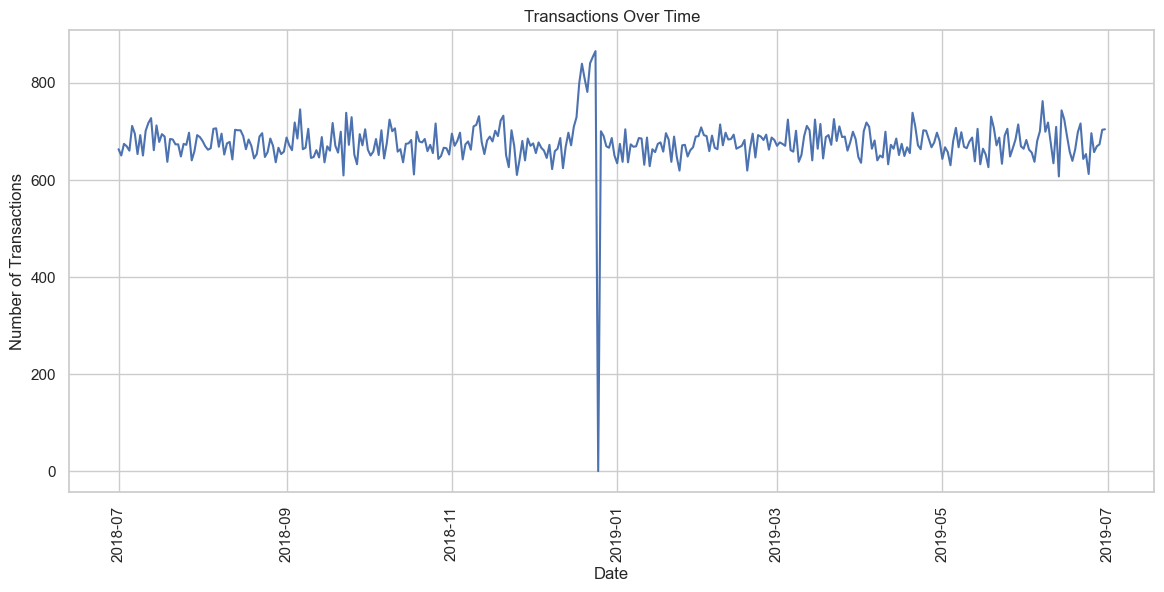

In [24]:
plt.figure(figsize=(14,6))

plt.plot(transactions_by_day['DATE'], transactions_by_day['N'])

plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=90)
plt.show()

In [26]:
transaction_data['PACK_SIZE'] = transaction_data['PROD_NAME'].str.extract(r'(\d+)').astype(int)

In [27]:
transaction_data['PACK_SIZE'].value_counts().sort_index()

PACK_SIZE
70      1507
90      3008
110    22387
125     1454
134    25102
135     3257
150    40203
160     2970
165    15297
170    19983
175    66390
180     1468
190     2995
200     4473
210     6272
220     1564
250     3169
270     6285
330    12540
380     6416
Name: count, dtype: int64

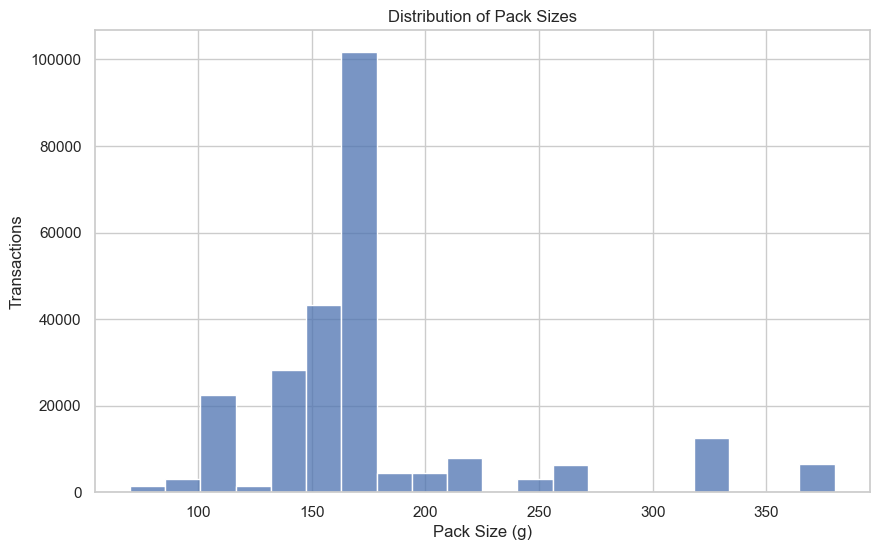

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(transaction_data['PACK_SIZE'], bins=20)

plt.title("Distribution of Pack Sizes")
plt.xlabel("Pack Size (g)")
plt.ylabel("Transactions")

plt.show()

In [32]:
transaction_data['BRAND'] = transaction_data['PROD_NAME'].str.split().str[0]

In [39]:
transaction_data['BRAND'] = transaction_data['BRAND'].replace({
    'RED': 'Red',
    'Snbts': 'Sunbites',
    'Infzns': 'Infuzions',
    'Doritos' : 'Dorito'
})

In [40]:
transaction_data['BRAND'].value_counts()

BRAND
Kettle        41288
Smiths        27390
Dorito        25224
Pringles      25102
Red           16321
Infuzions     14201
Thins         14075
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Sunbites       3008
Smith          2963
Cheetos        2927
Burger         1564
Woolworths     1516
GrnWves        1468
NCC            1419
French         1418
Name: count, dtype: int64

In [41]:
customer_data.info()
customer_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [43]:
customer_data['LIFESTAGE'].value_counts()
customer_data['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [44]:
data = pd.merge(
    transaction_data,
    customer_data,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [45]:
data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [46]:
data['SALES'] = data['PROD_QTY'] * data['TOT_SALES']

In [47]:
sales_segment = data.groupby(
    ['LIFESTAGE','PREMIUM_CUSTOMER']
)['SALES'].sum().reset_index()

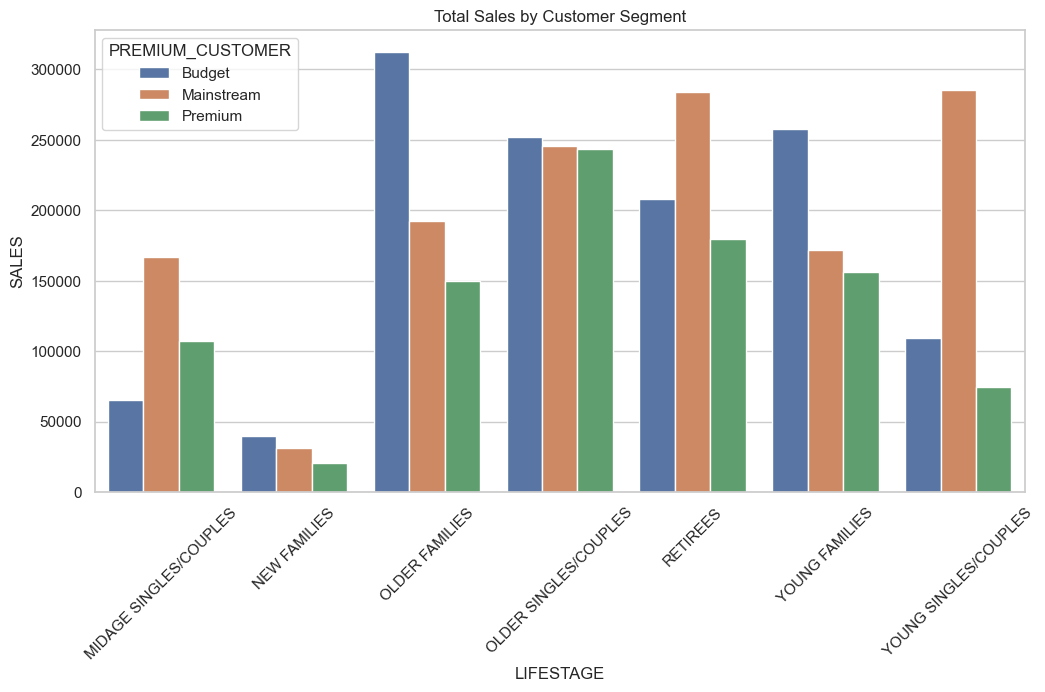

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sales_segment,
    x='LIFESTAGE',
    y='SALES',
    hue='PREMIUM_CUSTOMER'
)

plt.xticks(rotation=45)
plt.title("Total Sales by Customer Segment")

plt.show()

In [49]:
customers_segment = data.groupby(
    ['LIFESTAGE','PREMIUM_CUSTOMER']
)['LYLTY_CARD_NBR'].nunique().reset_index()

Text(0.5, 1.0, 'Total Sales by life stage')

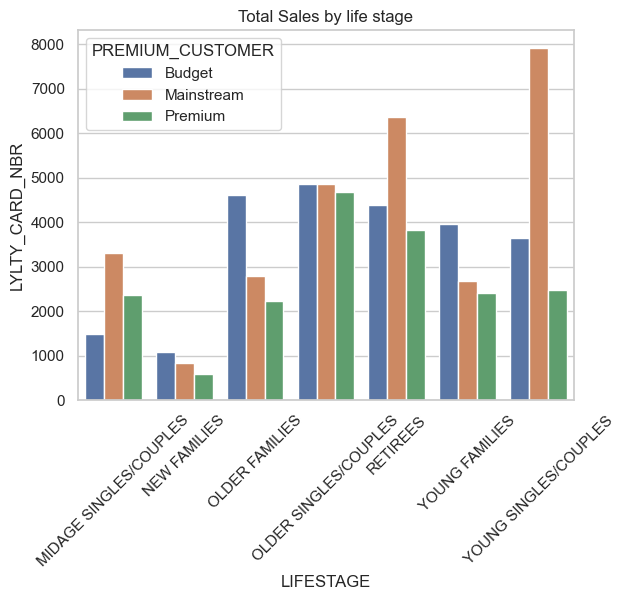

In [52]:
sns.barplot(
    data=customers_segment,
    x='LIFESTAGE',
    y='LYLTY_CARD_NBR',
    hue='PREMIUM_CUSTOMER'
)
plt.xticks(rotation=45)
plt.title("Total Sales by life stage")

In [53]:
units_segment = data.groupby(
    ['LIFESTAGE','PREMIUM_CUSTOMER']
)['PROD_QTY'].mean().reset_index()

In [54]:
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']

In [55]:
price_segment = data.groupby(
    ['LIFESTAGE','PREMIUM_CUSTOMER']
)['PRICE_PER_UNIT'].mean().reset_index()

In [56]:
from scipy.stats import ttest_ind

mainstream = data[
    data['PREMIUM_CUSTOMER']=='Mainstream'
]['PRICE_PER_UNIT']

budget = data[
    data['PREMIUM_CUSTOMER']=='Budget'
]['PRICE_PER_UNIT']

t_stat, p_value = ttest_ind(mainstream, budget)

print(p_value)

4.470267057639219e-46


In [57]:
segment = data[
    (data['LIFESTAGE']=="YOUNG SINGLES/COUPLES") &
    (data['PREMIUM_CUSTOMER']=="Mainstream")
]

segment['BRAND'].value_counts(normalize=True)

BRAND
Kettle        0.196684
Dorito        0.121725
Pringles      0.118451
Smiths        0.091588
Infuzions     0.063958
Thins         0.059660
Twisties      0.046050
Tostitos      0.045538
Red           0.044771
Cobs          0.044208
Tyrrells      0.031672
Grain         0.029472
WW            0.021643
Cheezels      0.017704
Natural       0.016424
CCs           0.011359
Cheetos       0.008494
Smith         0.006703
Sunbites      0.006549
French        0.003991
NCC           0.003735
GrnWves       0.003582
Burger        0.003172
Woolworths    0.002865
Name: proportion, dtype: float64

In [58]:
segment['PACK_SIZE'].value_counts(normalize=True)

PACK_SIZE
175    0.255679
150    0.157593
134    0.118451
110    0.104943
170    0.080587
330    0.061144
165    0.056386
380    0.032030
270    0.031723
210    0.029472
135    0.014838
250    0.014327
200    0.009159
190    0.007573
90     0.006549
160    0.006549
180    0.003582
70     0.003223
220    0.003172
125    0.003019
Name: proportion, dtype: float64